# Problem Set 3
## INF266- Reinforcement Learning


## Part 1

# 1 Monte Carlo methods

#### Task 1.8:

Both estimates change downwards when redefining x_2 as x_1 + uniformly drawn noise.
In the first case, the samples are drawn uniformly over the square, so the fraction of points inside the circle correctly estimates the area ratio 𝜋/4. The estimator is therefore unbiased, and the only error comes from Monte Carlo variance.
In the second case, the samples are no longer uniformly distributed because 𝑥2	​depends on x1. The points are concentrated along a diagonal band instead of covering the square evenly. As a result, the computed fraction inside the circle no longer represents the true area ratio, and the estimator becomes biased.

# 2 MC and MABs

#### Task 2.1
A multi-armed bandit is a control problem.
The objective is not only to estimate expected rewards, but to choose actions in order to maximize cumulative reward. This corresponds to policy optimization.
#### Task 2.2:
The expected rewards of arms correspond to an action-value function.
In a MAB there is effectively only one state, so: Q(a)=E[R∣a]
We estimate the expected reward of each arm.
#### Task 2.3:
Normally a trajectory is: (State,Action,Reward,State)
In a MAB, there are no state transitions, so a trajectory reduces to (Action,reward)
A collection of trajectories is simply a sequence of independent action–reward pairs.
#### Task 2.4:
MC control.
Estimates Q(a) via sample averages,
Improve the policy by acting greedily with respect to Q
This matches the MC control framework (policy evaluation + policy improvement).
#### Task 2.5:
MC prediction corresponds to estimating: Q(a)=E[R∣a]
under a fixed policy, without performing policy improvement.
#### Task 2.6:
In both MABs and Monte Carlo control, ε ensures exploration.
In MABs, ε prevents premature commitment to a suboptimal arm.
In Monte Carlo control, ε-soft policies guarantee sufficient exploration of all state–action pairs, which is required for convergence.
#### Task 2.7:
Yes, a standard reinforcement learning problem can be reduced to a MAB by removing state transitions and environment dynamics.
However, this removes:

    Sequential decision structure
    State-dependent values
    Long-term credit assignment
    Planning over time
The problem becomes a single-state, stateless decision problem.

# 3 Importance Sampling

#### Task 3.4:


In [76]:
import numpy as np
rewards_R = [0, 5, 10, 20]
probs_R   = [.35, .3, .25, .1]

rewards_S = [0, 5, 10, 20]
probs_S   = [.3, .35, .3, .05]

rho = np.array(probs_R) / np.array(probs_S)
print("\nRatio between the distribution probability of R and S:")
for reward, r in zip(rewards_R, rho):
    print(f"Reward {reward}: rho = {r}")



Ratio between the distribution probability of R and S:
Reward 0: rho = 1.1666666666666667
Reward 5: rho = 0.8571428571428572
Reward 10: rho = 0.8333333333333334
Reward 20: rho = 2.0


#### Task 3.5:

In [77]:
#helpers from 3.1 and 3.3 in order to run 3.5
expected_R = np.sum(np.array(rewards_R) * np.array(probs_R))
samples_S = np.random.choice(rewards_S, size=10000, p=probs_S)

#3.5
ratio_dict = dict(zip(rewards_R, rho))
weights = np.array([ratio_dict[x] for x in samples_S])

IS_estimate_R = np.mean(weights * samples_S)

print("\nIS estimate of E[R] using samples from S:")
print(f"E_hat_IS[R]: {IS_estimate_R}")
print(f"True E[R]: {expected_R}")
print(f"IS Error: {IS_estimate_R - expected_R}")


IS estimate of E[R] using samples from S:
E_hat_IS[R]: 6.208809523809523
True E[R]: 6.0
IS Error: 0.20880952380952333


#### Task 3.8: 
From caomparison of E[R]: 
From S:   5.983595238095238

From S (R_prime)':  5.9786

From S (R_double)': 6.613326653306612


The results differ because the variance of importance sampling depends on how close the behavior distribution is to the target distribution.
When sampling from S, which is similar to R, the importance weights remain moderate and the estimate of 
E[R] is stable. With S′, all rewards have reasonable probability, so the estimator remains fairly stable.
However, with S″, some rewards have very small probability under the behavior distribution but higher probability under R. This produces large importance weights and therefore high variance, causing the estimate to fluctuate significantly.
In general, the larger the mismatch between behavior and target distribution, the higher the variance of the importance sampling estimator.

# 4 Q-Learning


#### Task 4.1

We do not need importance sampling in Q-learning because the update does not attempt to evaluate the expected return of a target policy using trajectories generated by a different behavior policy.

Instead, Q-learning applies the Bellman optimality backup:
Q(s,a)← Q(s,a)+α[r+γ max Q(s′,a′)− Q(s,a)]

The target depends on the maximum estimated action-value in the next state, not on the action actually taken by the behavior policy. Therefore, the update is independent of the behavior policy’s action probabilities.
Q-learning is inherently off-policy, it learns the optimal value function. Since it bootstraps toward the optimal value rather than estimating expectations under a specific target policy, importance sampling ratios are not required.

## Part 2

In [78]:
#Code from 5.1-5.3 needed to run 5.4
from collections import defaultdict
from pathlib import Path
import numpy as np
import pickle

traj_rel = Path("src/mountain_2/mountain/envs/trajectories.pickle")
traj_path = next((base / traj_rel for base in [Path.cwd(), *Path.cwd().parents] if (base / traj_rel).exists()), None)

with open(traj_path, "rb") as f:
    trajectories = pickle.load(f)

gamma = 1.0  #No discounting, total accumulated reward

def MC_action_value(trajectories, gamma=1.0):
    return_sum = defaultdict(float)
    return_count = defaultdict(int)

    for episode in trajectories:
        G = 0.0
        returns_from_t = [0.0] * len(episode)

        for t in reversed(range(len(episode))):
            _, _, r_t1, _ = episode[t]
            G = r_t1 + gamma * G
            returns_from_t[t] = G

        visited = set()
        for t, (s, a, _, _) in enumerate(episode):
            sa = (s, a)
            if sa not in visited:
                visited.add(sa)
                return_sum[sa] += returns_from_t[t]
                return_count[sa] += 1

    return {sa: return_sum[sa] / return_count[sa] for sa in return_sum}

q_pi = MC_action_value(trajectories, gamma)

#### Task 5.4
Yes, we can perform MC improvement by defining a new policy
pi'(s) = arg max_a q_pi(s,a)
that is, choosing the action with the highest estimated action-value for each state.

However, the new policy is not guaranteed to be optimal. The estimates were computed from offline trajectories generated by the original policy. After improvement, the new policy may select actions that were rarely or never taken in the dataset, meaning their value estimates may be inaccurate. Without collecting new trajectories and repeating evaluation and improvement, optimality cannot be guaranteed.


In [79]:
#whole clue with mc-improvement, as we remember from lecture is that we can select an action that maximizes q_pi(s,a) for each state s to get an improved policy.
def MC_improvement_from_q(q_pi):
    q_by_state = defaultdict(dict)
    for (state, action), q_val in q_pi.items():
        q_by_state[state][action] = q_val

    improved_policy = {}
    for state, action_values in q_by_state.items():
        best_action = max(action_values, key=action_values.get)
        improved_policy[state] = best_action
    return improved_policy, q_by_state

improved_policy, q_by_state = MC_improvement_from_q(q_pi)
print("States with improved action:", len(improved_policy))

States with improved action: 2924


#### Task 5.5
Not all trajectories are equally useful for Monte Carlo evaluation and improvement. The quality of the estimates depends on how often each state–action pair is visited: frequently visited pairs yield low-variance estimates, while rarely visited pairs remain noisy or undefined. Trajectories that explore diverse states and actions contribute more information than repetitive ones following the same path. Longer trajectories are only more valuable if they cover new state–action pairs. Since the dataset was generated under a fixed policy, poorly explored actions cannot be reliably compared, which limits the quality of the improvement step.

#### Task 5.6
At this point in the hw, we have no simulator for M, only trajectories, which are not sufficient for implementing MC-control

#### Task 5.7
We choose an ε-greedy policy with relatively high exploration. The environment is stochastic and contains a large state space (31×100 grid), making sufficient exploration necessary for reliable estimation of action-values. Since Monte Carlo control updates only after full episodes and relies entirely on observed returns, inadequate exploration would result in poor state–action coverage and unreliable estimates. A sufficiently exploratory starting policy therefore reduces the risk of premature convergence to suboptimal paths and improves the stability of early learning.

#### Task 5.9
MC control improved performance significantly and learned near-optimal behavior. However, convergence was very slow and computationally expensive due to high variance, long episodes, and stochastic transitions. The policy approached optimality but was not perfectly converged. The main challenges were sample inefficiency and computational cost.

#### 5.12
We evaluated the algorithms using episode return and a moving average over a fixed window (200 episodes) to smooth variability and capture the learning trend. From the moving-average learning curve, SARSA(0) learns faster and produces a more stable improvement pattern than Monte Carlo. MC has higher variance because it relies on full-episode returns, while SARSA(0) updates online using bootstrapping, which improves learning stability and sample efficiency. Overall, SARSA(0) outperformed MC in learning speed and stability.

In [80]:
N_ACTIONS = 5
FORWARD_ACTIONS = [0, 2, 4]
OTHER_ACTIONS   = [1, 3]
N_EPISODES = 50_000
MAX_STEPS = 1000

def starting_policy(state):
    probs = np.zeros(N_ACTIONS)
    probs[FORWARD_ACTIONS] = 0.9 / len(FORWARD_ACTIONS)
    probs[OTHER_ACTIONS]   = 0.1 / len(OTHER_ACTIONS)
    return probs

def generate_episode(env, policy):
    obs, _ = env.reset()
    state = tuple(obs["agent"]["pos"])
    episode = []

    while True:
        action = np.random.choice(N_ACTIONS, p=policy(state))
        obs, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = tuple(obs["agent"]["pos"])
        if terminated or truncated:
            break

    return episode

def mc_control(env, n_episodes=N_EPISODES, gamma=1.0, epsilon=0.1):
    Q = defaultdict(lambda: np.zeros(N_ACTIONS))
    N = defaultdict(lambda: np.zeros(N_ACTIONS))
    policy = starting_policy
    ep_returns = []

    for _ in range(n_episodes):
        episode = generate_episode(env, policy)
        ep_returns.append(sum(r for _, _, r in episode))

        G = 0.0
        visited = set()

        for s, a, r in reversed(episode):
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                N[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / N[s][a]

        # ε-greedy improvement
        def policy(state, _Q=Q):
            probs = np.ones(N_ACTIONS) * epsilon / N_ACTIONS
            probs[np.argmax(_Q[state])] += 1.0 - epsilon
            return probs

    def greedy_policy(state):
        probs = np.zeros(N_ACTIONS)
        probs[np.argmax(Q[state])] = 1.0
        return probs

    return Q, greedy_policy, np.array(ep_returns)

def train_sarsa_with_history(env, n_episodes=N_EPISODES, gamma=1.0, alpha=0.1, epsilon=0.1):
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    episode_returns = []

    def eps_greedy(state):
        if np.random.rand() < epsilon:
            return np.random.randint(n_actions)
        return int(np.argmax(Q[state]))

    for _ in range(n_episodes):
        obs, _ = env.reset()
        s = tuple(obs["agent"]["pos"])
        a = eps_greedy(s)
        total = 0.0

        while True:
            obs, r, terminated, truncated, _ = env.step(a)
            s2 = tuple(obs["agent"]["pos"])
            done = terminated or truncated
            total += r

            if done:
                target = r
            else:
                a2 = eps_greedy(s2)
                target = r + gamma * Q[s2][a2]

            Q[s][a] += alpha * (target - Q[s][a])

            if done:
                break

            s, a = s2, a2

        episode_returns.append(total)

    return Q, np.array(episode_returns)

/opt/anaconda3/envs/INF161/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment mountain/GridWorld-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/opt/anaconda3/envs/INF161/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment mountain/GridWorld-v2 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/opt/anaconda3/envs/INF161/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
/opt/anaconda3/envs/INF161/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.

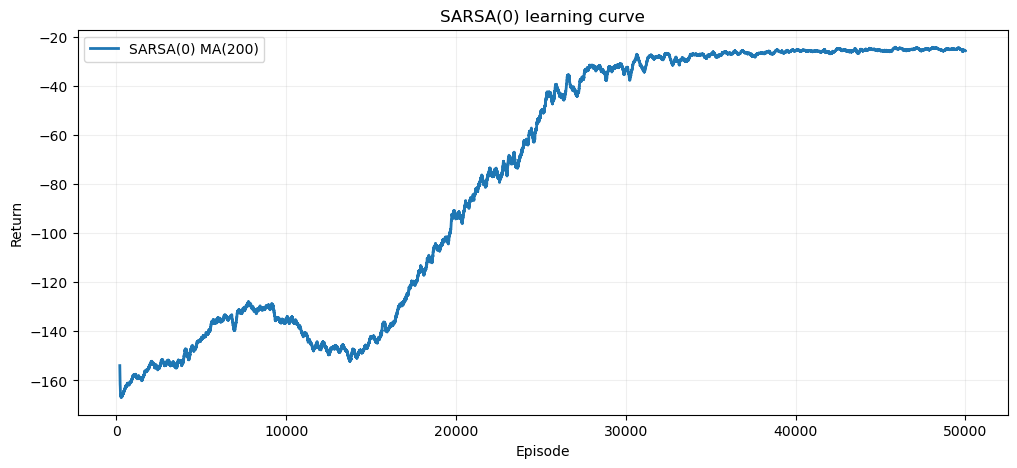

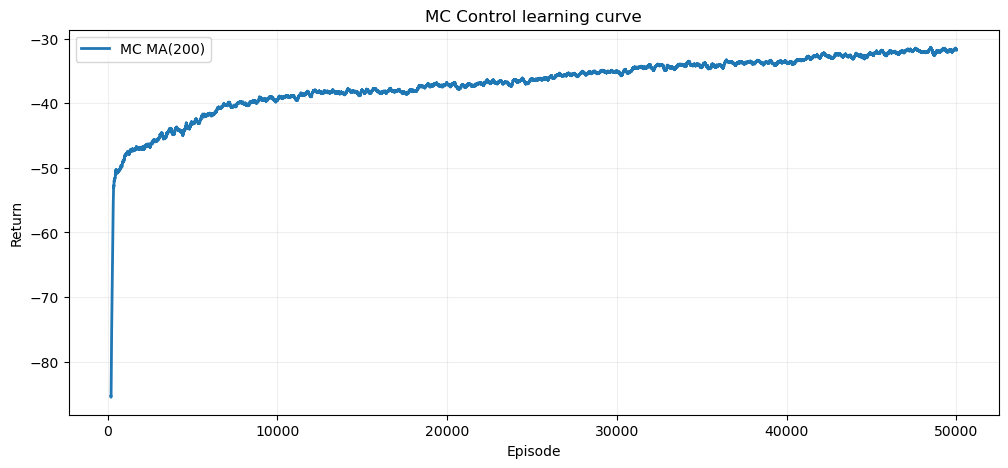

In [81]:
import gymnasium
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import importlib
import sys
import gymnasium as gym


# Force-load local package that registers mountain/GridWorld-v1,v2
pkg_root = Path.cwd() / "src" / "mountain_2"
sys.path.insert(0, str(pkg_root.resolve()))
sys.modules.pop("mountain", None)   
importlib.import_module("mountain") 

env_2 = gym.make("mountain/GridWorld-v2")

window = 200
ma = lambda x: np.convolve(x, np.ones(window)/window, mode="valid")

_, sarsa_returns = train_sarsa_with_history(env_2, n_episodes=N_EPISODES, alpha=0.1, epsilon=0.1)
plt.figure(figsize=(12,5))
plt.plot(np.arange(window-1, len(sarsa_returns)), ma(sarsa_returns), linewidth=2, label=f"SARSA(0) MA({window})")
plt.xlabel("Episode"); plt.ylabel("Return"); plt.title("SARSA(0) learning curve"); plt.legend(); plt.grid(alpha=0.2)
plt.show()

_, _, mc_returns = mc_control(env_2, n_episodes=N_EPISODES, epsilon=0.1)
plt.figure(figsize=(12,5))
plt.plot(np.arange(window-1, len(mc_returns)), ma(mc_returns), linewidth=2, label=f"MC MA({window})")
plt.xlabel("Episode"); plt.ylabel("Return"); plt.title("MC Control learning curve"); plt.legend(); plt.grid(alpha=0.2)
plt.show()


#### Task 5.14

In [82]:

def epsilon_greedy_action(Q, state, epsilon, n_actions):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state]))
def sarsa_n(env, n=4, n_episodes=N_EPISODES, gamma=1.0, alpha=0.05, epsilon=0.1):
    #init 
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    ep_returns = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        start_state = tuple(obs["agent"]["pos"])
        start_action = epsilon_greedy_action(Q, start_state, epsilon, n_actions)
        episode_return = 0.0

        #Buffers for one episode trajectory:
        #states[k] = S_k, actions[k] = A_k, rewards[k] = R_k (with rewards[1] = first real reward)
        states = [start_state]
        actions = [start_action]
        rewards = [0.0]  #dummy so indexing matches RL notation (R_{t+1})

        T = np.inf  #terminal time step (unknown until episode ends)
        t = 0

        while True:
            # 1)Interact with environment while episode not ended
            if t < T:
                obs, reward, terminated, truncated, _ = env.step(actions[t])
                rewards.append(reward)                         #stores R_{t+1}
                episode_return += reward
                next_state = tuple(obs["agent"]["pos"])
                states.append(next_state)                      #stores S_{t+1}

                if terminated or truncated:
                    T = t + 1                                  #episode ends at time T
                else:
                    next_action = epsilon_greedy_action(Q, next_state, epsilon, n_actions)
                    actions.append(next_action)                #stores A_{t+1}

            # 2)Decide which earlier time index can be updated now
            #tau is the state-action index whose n-step target is now available (fully or partially)
            tau = t - n + 1

            if tau >= 0:
                # 3)Build the n-step target G for (S_tau, A_tau)
                #General form:
                #G = R_{tau+1} + gamma*R_{tau+2} + ... + gamma^{n-1}*R_{tau+n}
                #    + gamma^n * Q(S_{tau+n}, A_{tau+n})   [only if tau+n < T]

                if np.isinf(T):
                    upper = tau + n
                else:
                    upper = min(tau + n, int(T))

                #Reward-only part:
                #sum_{i=tau+1}^{upper} gamma^{i-tau-1} * R_i
                G = 0.0
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]

                #Bootstrap part if we have not hit terminal before tau+n
                #(i.e., still have an action A_{tau+n} to bootstrap from)
                if tau + n < T:
                    G += (gamma ** n) * Q[states[tau + n]][actions[tau + n]]

                #4) Update Q at the delayed index tau
                state_tau, action_tau = states[tau], actions[tau]
                Q[state_tau][action_tau] += alpha * (G - Q[state_tau][action_tau])

            #5) Stop when the final eligible tau (T-1) has been updated
            if tau == T - 1:
                break

            t += 1

        ep_returns.append(episode_return)

    return Q, np.array(ep_returns)

Q_sarsa3, sarsa3_returns = sarsa_n(env_2, n=3, n_episodes=N_EPISODES, gamma=1.0, alpha=0.05, epsilon=0.1)
Q_sarsa4, sarsa4_returns = sarsa_n(env_2, n=4, n_episodes=N_EPISODES, gamma=1.0, alpha=0.05, epsilon=0.1)
Q_sarsa5, sarsa5_returns = sarsa_n(env_2, n=5, n_episodes=N_EPISODES, gamma=1.0, alpha=0.05, epsilon=0.1)

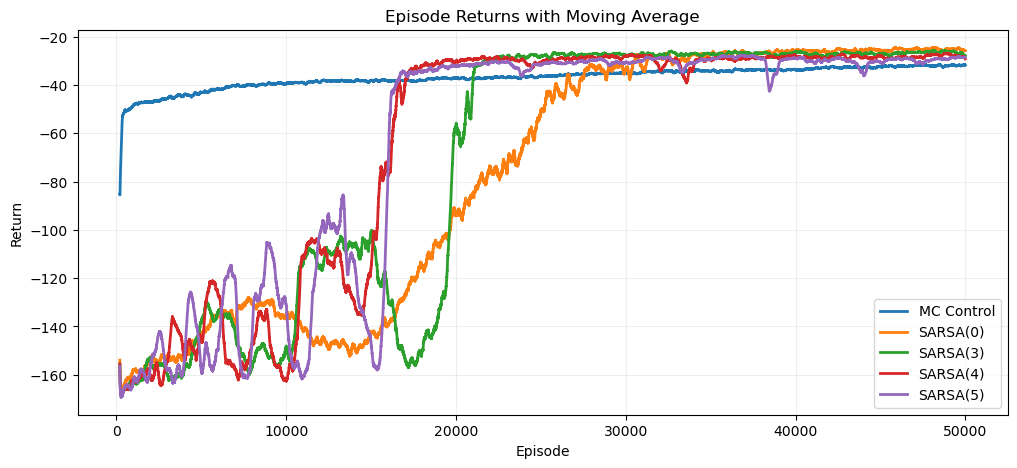

In [83]:
def plot_returns(*args, labels=None, window=200):
    plt.figure(figsize=(12, 5))
    for i, returns in enumerate(args):
        ma = np.convolve(returns, np.ones(window)/window, mode="valid")
        label = labels[i] if labels else f"Returns {i+1}"
        plt.plot(np.arange(window-1, len(returns)), ma, linewidth=2, label=label)
    plt.title("Episode Returns with Moving Average")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_returns(mc_returns, sarsa_returns, sarsa3_returns, sarsa4_returns, sarsa5_returns, labels=["MC Control", "SARSA(0)", "SARSA(3)", "SARSA(4)", "SARSA(5)"])  


#### Task 5.16

In [ ]:
# 5.15
def q_learning(env, n_episodes=N_EPISODES, gamma=1.0, alpha=0.05, epsilon=0.1):
    n_actions = env.action_space.n
    Q_q = defaultdict(lambda: np.zeros(n_actions))
    ep_returns_q = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        state = tuple(obs["agent"]["pos"])
        done = False
        episode_return = 0.0

        #implementation of greedy action selection inside the loop, compared to a defined function as prev. 
        while not done:
            if np.random.rand() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = int(np.argmax(Q_q[state]))

            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = tuple(obs["agent"]["pos"])
            done = terminated or truncated
            episode_return += reward

            if done:
                target = reward
            else:
                target = reward + gamma * np.max(Q_q[next_state])

            Q_q[state][action] += alpha * (target - Q_q[state][action])
            state = next_state

        ep_returns_q.append(episode_return)

    return Q_q, np.array(ep_returns_q)

Q_q, q_returns = q_learning(env_2, n_episodes=N_EPISODES, gamma=1.0, alpha=0.05, epsilon=0.1)


In [88]:
_, sarsa_returns = train_sarsa_with_history(env_2, n_episodes=100_000, alpha=0.1, epsilon=0.1)

In [ ]:
Q_q, q_returns = q_learning(env_2, n_episodes=100_000, gamma=1.0, alpha=0.05, epsilon=0.1)

In [ ]:
_, _, mc_returns = mc_control(env_2, n_episodes=60_0000, epsilon=0.1)

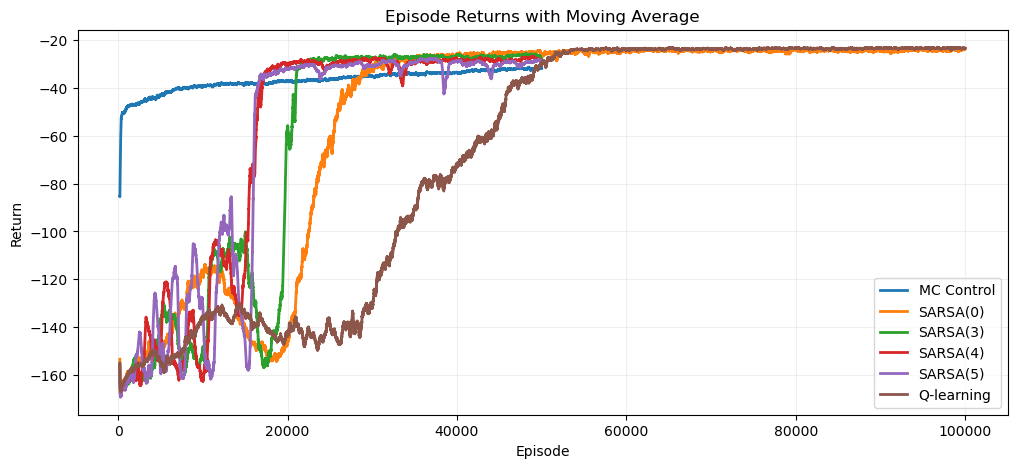

Final-window mean return (last 1000 episodes):
MC Control : -31.804
SARSA(0)   : -24.047
SARSA(3)   : -26.846
SARSA(4)   : -28.183
SARSA(5)   : -28.535
Q-learning : -23.394


In [89]:
#5.16
# Metric for comparison: moving-average episode return + final-window average return
window = 200
plot_returns(
    mc_returns,
    sarsa_returns,
    sarsa3_returns,
    sarsa4_returns,
    sarsa5_returns,
    q_returns,
    labels=["MC Control", "SARSA(0)", "SARSA(3)", "SARSA(4)", "SARSA(5)", "Q-learning"],
    window=window,
)

# Numeric summary from same metric family (higher/less-negative is better)
def final_window_mean(returns, w=1000):
    w = min(w, len(returns))
    return float(np.mean(returns[-w:]))

print("Final-window mean return (last 1000 episodes):")
print(f"MC Control : {final_window_mean(mc_returns):.3f}")
print(f"SARSA(0)   : {final_window_mean(sarsa_returns):.3f}")
print(f"SARSA(3)   : {final_window_mean(sarsa3_returns):.3f}")
print(f"SARSA(4)   : {final_window_mean(sarsa4_returns):.3f}")
print(f"SARSA(5)   : {final_window_mean(sarsa5_returns):.3f}")
print(f"Q-learning : {final_window_mean(q_returns):.3f}")